# 1.Data Curation & Preproccessing

In [6]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


Installing Dependencies and Libraries

In [7]:
!pip install chembl_webresource_client

import pandas as pd
from chembl_webresource_client.new_client import new_client

**Target Identification**

In [8]:
target = new_client.target
target_query = target.search("JAK2")
targets = pd.DataFrame.from_dict(target_query)
targets.head()

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,Tyrosine-protein kinase JAK2,18.0,False,CHEMBL2971,"[{'accession': 'O60674', 'component_descriptio...",SINGLE PROTEIN,9606
1,[],Rattus norvegicus,Tyrosine-protein kinase JAK2,18.0,False,CHEMBL1075225,"[{'accession': 'Q62689', 'component_descriptio...",SINGLE PROTEIN,10116
2,[],Mus musculus,Tyrosine-protein kinase JAK2,18.0,False,CHEMBL1649049,"[{'accession': 'Q62120', 'component_descriptio...",SINGLE PROTEIN,10090
3,[],Homo sapiens,Protein cereblon/Tyrosine-protein kinase JAK2,17.0,False,CHEMBL4742263,"[{'accession': 'O60674', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
4,[],Homo sapiens,JAK2/TYK2,16.0,False,CHEMBL3301392,"[{'accession': 'O60674', 'component_descriptio...",PROTEIN COMPLEX,9606


Reterive Bioactivity data for selected target

In [9]:
selected_target = targets.target_chembl_id[0]
selected_target

'CHEMBL2971'

Now retrieve only bioactivity data for JAK2

In [10]:
activity = new_client.activity
results = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")


In [11]:
df1 = pd.DataFrame.from_dict(results)
df1.head(5)


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,129350,[],CHEMBL704111,Inhibition of Janus kinase 2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,uM,UO_0000065,None,10.0
1,None,None,506160,[],CHEMBL704109,Inhibition of protein kinase Jak 2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,uM,UO_0000065,None,0.001
2,None,None,1257904,[],CHEMBL704112,Inhibition of Janus kinase 2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,1748676,[],CHEMBL870360,Inhibition of JAK2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,uM,UO_0000065,None,0.24
4,None,None,1807585,[],CHEMBL908418,Inhibition of JAK2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,nM,UO_0000065,None,11.0


In [12]:
df1.standard_type.unique()

array(['IC50'], dtype=object)

In [13]:
df1.to_csv('bioactivity_raw_data.csv', index=False)

Save the resulting bioactivity data to a CSV file *bioactivityJAK2_raw_data*.csv.

In [14]:
df1.to_csv('bioactivity_raw_data.csv', index=False)
! cp bioactivity_raw_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"

! ls -l "/content/gdrive/My Drive/Colab Notebooks/data"

! head bioactivity_raw_data.csv

total 24866
-rw------- 1 root root     5612 Mar 17 23:07 bioactivity_preprocessed_data.csv
-rw------- 1 root root 25456503 Apr 27 12:34 bioactivity_raw_data.csv
action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
,,129350,[],CHEMBL704111,Inhibition of Janus kinase 2,B,,,BAO_0000190,BAO_0000357,single protein format,O=C1NCc2c(-c3ccc(F)cc3F)cc(C3CCNCC3)cc2N1c1c(

# Bioactivity Data Retrieval (IC50)

Inspect Missing Values

In [15]:
df1["standard_type"].isna().sum()

np.int64(0)

Filter Rows with Valid Bioactivity Values

In [16]:
df2 = df1[df1["standard_value"].notna()]
df2.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,129350,[],CHEMBL704111,Inhibition of Janus kinase 2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,uM,UO_0000065,None,10.0
1,None,None,506160,[],CHEMBL704109,Inhibition of protein kinase Jak 2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,uM,UO_0000065,None,0.001
2,None,None,1257904,[],CHEMBL704112,Inhibition of Janus kinase 2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,uM,UO_0000065,None,50.0
3,None,None,1748676,[],CHEMBL870360,Inhibition of JAK2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,uM,UO_0000065,None,0.24
4,None,None,1807585,[],CHEMBL908418,Inhibition of JAK2,B,None,None,BAO_0000190,...,Homo sapiens,Tyrosine-protein kinase JAK2,9606,None,None,IC50,nM,UO_0000065,None,11.0


Assign Classes


In [17]:
bioactivity_class = []
for value in df2.standard_value:
    value = float(value)
    if value >= 10000:
        bioactivity_class.append("inactive")
    elif value <= 1000:
        bioactivity_class.append("active")
    else:
        bioactivity_class.append("intermediate")


Extract Relevant Columns

In [18]:
molecule_ids = df2.molecule_chembl_id.tolist()
canonical_smiles = df2.canonical_smiles.tolist()
standard_values = df2.standard_value.tolist()


In [19]:
data = list(zip(
    molecule_ids,
    canonical_smiles,
    standard_values,
        bioactivity_class,
))



Preprocessed Data Creation



In [20]:
df3 = pd.DataFrame(
    data,
    columns=[
        "molecule_chembl_id",
        "canonical_smiles",
        "standard_value",
        "bioactivity_class",
    ]
)
df3.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL319556,O=C1NCc2c(-c3ccc(F)cc3F)cc(C3CCNCC3)cc2N1c1c(C...,10000.0,inactive
1,CHEMBL21156,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,1.0,active
2,CHEMBL104466,COc1cc2ncc(N[C@H]3CC[C@H](O)CC3)nc2cc1OC,50000.0,inactive
3,CHEMBL386760,COc1ccc(N(C(=O)Oc2c(C)cccc2C)c2ccnc(Nc3cc(OC)c...,240.0,active
4,CHEMBL221959,C[C@@H]1CCN(C(=O)CC#N)C[C@@H]1N(C)c1ncnc2[nH]c...,11.0,active


Remove Compounds without Valid SMILES. Drop rows with NaN, empty or None SMILES values.

In [21]:
df3 = df3.dropna(subset=["canonical_smiles"])
df3 = df3[df3["canonical_smiles"].str.lower() != "none"]
df3 = df3[df3["canonical_smiles"].str.strip() != ""]
df3.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL319556,O=C1NCc2c(-c3ccc(F)cc3F)cc(C3CCNCC3)cc2N1c1c(C...,10000.0,inactive
1,CHEMBL21156,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,1.0,active
2,CHEMBL104466,COc1cc2ncc(N[C@H]3CC[C@H](O)CC3)nc2cc1OC,50000.0,inactive
3,CHEMBL386760,COc1ccc(N(C(=O)Oc2c(C)cccc2C)c2ccnc(Nc3cc(OC)c...,240.0,active
4,CHEMBL221959,C[C@@H]1CCN(C(=O)CC#N)C[C@@H]1N(C)c1ncnc2[nH]c...,11.0,active


Save Preprocessed Data

In [22]:
df3.to_csv("bioactivityJAK2_preprocessed_data.csv", index=False)
!cp bioactivity_preprocessed_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"
!ls "/content/gdrive/My Drive/Colab Notebooks/data"

cp: cannot stat 'bioactivity_preprocessed_data.csv': No such file or directory
bioactivity_preprocessed_data.csv  bioactivity_raw_data.csv


# 2. Exploratory Data Analysis
Import libraries for EDA

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

Bioactivity Dataset (**Preprocessed**)

In [24]:

df4 = pd.read_csv("bioactivityJAK2_preprocessed_data.csv")
df4.head(10)

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL319556,O=C1NCc2c(-c3ccc(F)cc3F)cc(C3CCNCC3)cc2N1c1c(C...,10000.0,inactive
1,CHEMBL21156,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,1.0,active
2,CHEMBL104466,COc1cc2ncc(N[C@H]3CC[C@H](O)CC3)nc2cc1OC,50000.0,inactive
3,CHEMBL386760,COc1ccc(N(C(=O)Oc2c(C)cccc2C)c2ccnc(Nc3cc(OC)c...,240.0,active
4,CHEMBL221959,C[C@@H]1CCN(C(=O)CC#N)C[C@@H]1N(C)c1ncnc2[nH]c...,11.0,active
5,CHEMBL557844,COC[C@H](C)Nc1cc(-c2ccoc2)nc(-n2cnc3ccncc32)n1.Cl,141.0,active
6,CHEMBL221378,C[C@H](Nc1cc(-c2ccoc2)nc(-n2cnc3ccncc32)n1)c1c...,28.0,active
7,CHEMBL375205,C[C@H](Nc1cc(-c2ccoc2)nc(-n2cnc3ccc(C#N)cc32)n...,29.0,active
8,CHEMBL220484,COC[C@H](C)Nc1cc(-c2ccoc2)nc(-n2cnc3ccncc32)n1,446.0,active
9,CHEMBL220969,C[C@H](Nc1cc(-c2cccc(C#N)c2)nc(-n2cnc3ccncc32)...,56.0,active


Remove N/A Values

In [25]:
print("Original shape:", df4.shape)

df4 = df4.dropna(subset=[
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value"
])

# convert IC50 to numeric
df4["standard_value"] = pd.to_numeric(df4["standard_value"], errors="coerce")

df4 = df4.dropna(subset=["standard_value"])

df4 = df4[df4["bioactivity_class"] != 'intermediate']

print("After cleaning:", df4.shape)


Original shape: (19025, 4)
After cleaning: (16816, 4)


In [26]:
df4.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL319556,O=C1NCc2c(-c3ccc(F)cc3F)cc(C3CCNCC3)cc2N1c1c(C...,10000.0,inactive
1,CHEMBL21156,CC(C)(C)c1nc2c3ccc(F)cc3c3c(=O)[nH]ccc3c2[nH]1,1.0,active
2,CHEMBL104466,COc1cc2ncc(N[C@H]3CC[C@H](O)CC3)nc2cc1OC,50000.0,inactive
3,CHEMBL386760,COc1ccc(N(C(=O)Oc2c(C)cccc2C)c2ccnc(Nc3cc(OC)c...,240.0,active
4,CHEMBL221959,C[C@@H]1CCN(C(=O)CC#N)C[C@@H]1N(C)c1ncnc2[nH]c...,11.0,active


Aggregate Duplicates IC50 (median IC50 per canonical smile)

In [27]:
df_clean = (
    df4
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "molecule_chembl_id": "first",
        "standard_value": "median",
        "bioactivity_class": "first"
    })
)

print("Before aggregation:", df4.shape[0])
print("After aggregation:", df_clean.shape[0])

df_clean.head()

Before aggregation: 16816
After aggregation: 10615


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class
0,Br.NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2,CHEMBL4242999,126.5,active
1,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,CHEMBL3918308,3.0,active
2,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,CHEMBL3942304,71.0,active
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,CHEMBL3927649,6.1,active
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,CHEMBL3979340,2.8,active


In [28]:
df_clean.standard_value.describe()

,standard_value
count,1.061500e+04
mean,2.566508e+04
std,5.491631e+05
min,0.000000e+00
25%,1.000000e+01
50%,5.930000e+01
75%,4.700000e+02
max,5.000000e+07


Convert IC50 to pIC50
Convert IC50 to the negative logarithmic scale which is essentially -log10(IC50). This conversion allows IC50 data to be more uniformly distributed.

In [29]:
df_clean["pIC50"] = -np.log10(df_clean["standard_value"] * 1e-9)

df_clean.head()


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,Br.NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2,CHEMBL4242999,126.5,active,6.897909
1,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,CHEMBL3918308,3.0,active,8.522879
2,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,CHEMBL3942304,71.0,active,7.148742
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,CHEMBL3927649,6.1,active,8.214670
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,CHEMBL3979340,2.8,active,8.552842


Reassign Activity Labels Based on PIC50
Based on pIC50
Active >= 6
Inactive < 6

In [30]:
threshold = 6

df_clean["bioactivity_class"] = np.where(
    df_clean["pIC50"] >= threshold,
    "active",
    "inactive"
)

df_clean.head()


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,Br.NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2,CHEMBL4242999,126.5,active,6.897909
1,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,CHEMBL3918308,3.0,active,8.522879
2,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,CHEMBL3942304,71.0,active,7.148742
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,CHEMBL3927649,6.1,active,8.214670
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,CHEMBL3979340,2.8,active,8.552842


Check **Duplicates**

In [31]:
print("Duplicate SMILES remaining:",
      df_clean["canonical_smiles"].duplicated().sum())

Duplicate SMILES remaining: 0


In [32]:
df_clean.standard_value.describe()

,standard_value
count,1.061500e+04
mean,2.566508e+04
std,5.491631e+05
min,0.000000e+00
25%,1.000000e+01
50%,5.930000e+01
75%,4.700000e+02
max,5.000000e+07


In [33]:
df_clean.pIC50.describe()

,pIC50
count,1.061500e+04
mean,inf
std,NaN
min,1.301030e+00
25%,6.327902e+00
50%,7.226945e+00
75%,8.000000e+00
max,inf


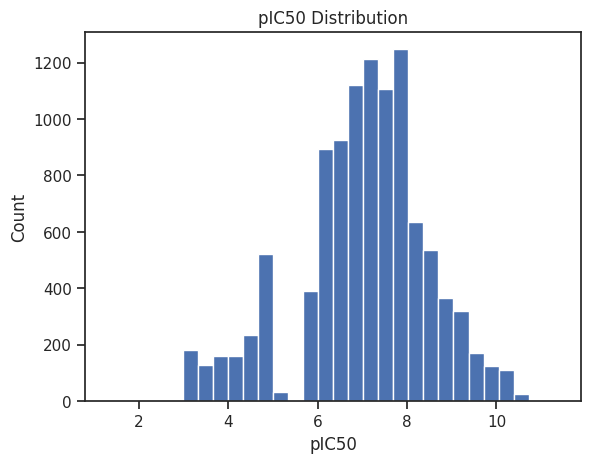

<Figure size 640x480 with 0 Axes>

In [34]:
df_finite_pic50 = df_clean[np.isfinite(df_clean['pIC50'])]

plt.hist(df_finite_pic50["pIC50"], bins=30)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("pIC50 Distribution")
plt.show()
plt.savefig('histogram_pic50.pdf')

Text(0, 0.5, 'Frequency')

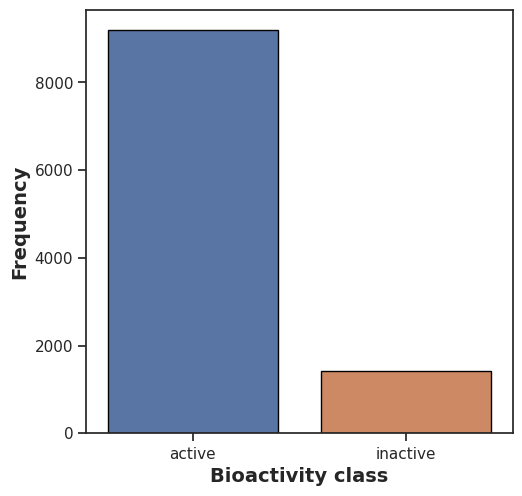

In [35]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_clean, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

## Lipinski's Descriptor

The Lipinski's Rule stated the following:

Molecular weight < 500 Dalton
Octanol-water partition coefficient (LogP) < 5
Hydrogen bond donors < 5
Hydrogen bond acceptors < 10

In [36]:
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import rdMolDescriptors

In [37]:
df_no_smiles = df_clean.drop(columns='canonical_smiles')

smiles = []

for i in df_clean.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key=len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name='canonical_smiles')

df_clean_smiles = pd.concat([df_no_smiles, smiles], axis=1)

df_clean_smiles

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL4242999,126.5,active,6.897909,NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2
1,CHEMBL3918308,3.0,active,8.522879,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1
2,CHEMBL3942304,71.0,active,7.148742,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br
3,CHEMBL3927649,6.1,active,8.214670,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1
4,CHEMBL3979340,2.8,active,8.552842,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1
...,...,...,...,...,...
10610,CHEMBL3891030,20.0,active,7.698970,c1coc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1
10611,CHEMBL3951230,10.0,active,8.000000,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1
10612,CHEMBL3981443,54.0,active,7.267606,c1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)n1
10613,CHEMBL3956418,38.0,active,7.420216,c1nc(CCNC[C@H]2CC[C@H](c3nnn4cnc5[nH]ccc5c34)C...


Calculate descriptors

In [38]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [39]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,326.400,2.0133,4.0,4.0
1,334.221,3.2743,1.0,3.0
2,496.232,4.5717,1.0,5.0
3,411.307,3.7477,1.0,4.0
4,401.268,3.3407,1.0,5.0


In [40]:
df_lipinski.shape

(10615, 4)

## **Combine Both datasets**

In [41]:
df_clean_smiles.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL4242999,126.5,active,6.897909,NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2
1,CHEMBL3918308,3.0,active,8.522879,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1
2,CHEMBL3942304,71.0,active,7.148742,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br
3,CHEMBL3927649,6.1,active,8.214670,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1
4,CHEMBL3979340,2.8,active,8.552842,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1


In [42]:
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,326.400,2.0133,4.0,4.0
1,334.221,3.2743,1.0,3.0
2,496.232,4.5717,1.0,5.0
3,411.307,3.7477,1.0,4.0
4,401.268,3.3407,1.0,5.0


In [43]:
df_combined = pd.concat([df_clean_smiles, df_lipinski], axis=1)
df_combined.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL4242999,126.5,active,6.897909,NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2,326.400,2.0133,4.0,4.0
1,CHEMBL3918308,3.0,active,8.522879,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,334.221,3.2743,1.0,3.0
2,CHEMBL3942304,71.0,active,7.148742,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,496.232,4.5717,1.0,5.0
3,CHEMBL3927649,6.1,active,8.214670,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,411.307,3.7477,1.0,4.0
4,CHEMBL3979340,2.8,active,8.552842,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,401.268,3.3407,1.0,5.0


In [44]:
df_combined = df_combined.drop(columns="standard_value")
df_combined.head()


,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL4242999,active,6.897909,NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2,326.400,2.0133,4.0,4.0
1,CHEMBL3918308,active,8.522879,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,334.221,3.2743,1.0,3.0
2,CHEMBL3942304,active,7.148742,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,496.232,4.5717,1.0,5.0
3,CHEMBL3927649,active,8.214670,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,411.307,3.7477,1.0,4.0
4,CHEMBL3979340,active,8.552842,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,401.268,3.3407,1.0,5.0


In [45]:
# Save CSV
df_combined.to_csv("df_lipinski.csv", index=False)

### Chemical Space Analysis For Lipinski Descriptors

Barplot of the bioactivity classes

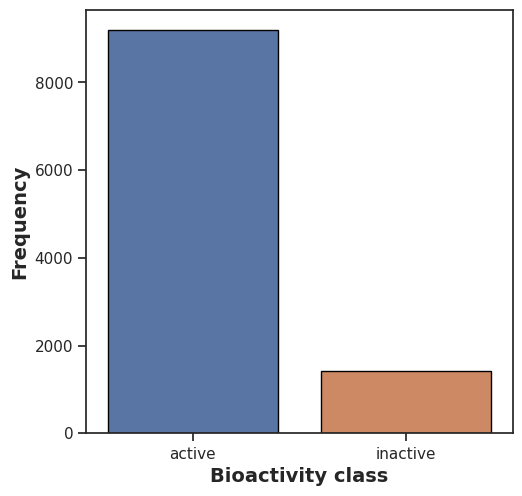

In [46]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_combined, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('barplot_bioactivity_class.pdf')

Boxplot of the bioactivity classes for PIC50

Text(0, 0.5, 'pIC50 value')

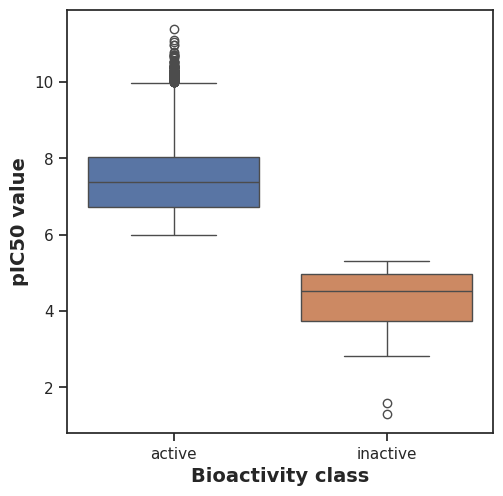

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "pIC50", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

Scatter of Molecular Weight vs Solubility (LogP)

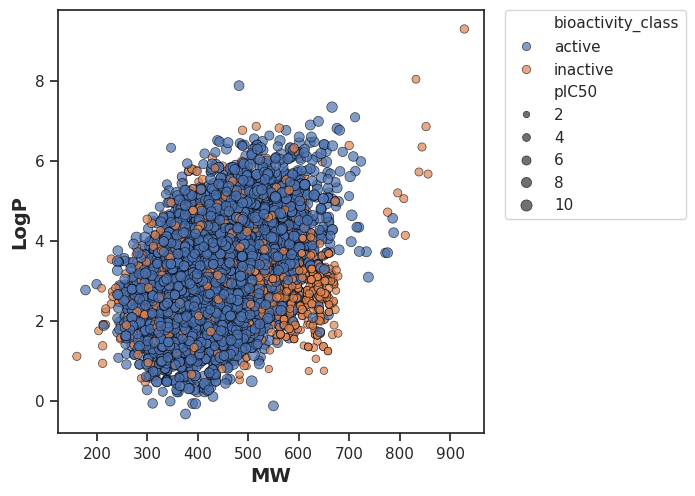

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_combined_finite = df_combined[np.isfinite(df_combined['pIC50'])]

plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_combined_finite, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('scatter_plot_MW_vs_LogP.pdf')

Statistical analysis (Mann-Whitney U Test)

In [51]:
def mannwhitney(descriptor, df_combined, verbose=False):
    """
    Perform Mann-Whitney U test between active and inactive compounds
    for a given descriptor.

    Parameters:
    - descriptor : str, column name of the descriptor
    - df_combined : pandas DataFrame, must have columns [descriptor, bioactivity_class]
    - verbose : bool, if True prints the test statistics

    Returns:
    - results : pandas DataFrame with test statistics, p-value, and interpretation
    """
    from numpy.random import seed
    from scipy.stats import mannwhitneyu
    import pandas as pd

    # set seed for reproducibility
    seed(1)

    # select only relevant columns
    df = df_combined[[descriptor, 'bioactivity_class']]

    # separate active and inactive compounds
    active = df[df['bioactivity_class'] == 'active'][descriptor]
    inactive = df[df['bioactivity_class'] == 'inactive'][descriptor]

    # perform Mann-Whitney U test
    stat, p = mannwhitneyu(active, inactive)

    if verbose:
        print(f"Descriptor: {descriptor}")
        print(f"Statistics={stat:.3f}, p={p:.3f}")

    # interpret result
    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    # store results in a DataFrame
    results = pd.DataFrame({
        'Descriptor': descriptor,
        'Statistics': stat,
        'p': p,
        'alpha': alpha,
        'Interpretation': interpretation
    }, index=[0])

    # save results to CSV
    filename = 'mannwhitneyu_' + descriptor + '.csv'
    results.to_csv(filename, index=False)

    return results

pIC50

In [53]:
mannwhitney("pIC50", df_combined, verbose=True)

Descriptor: pIC50
Statistics=13072446.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,13072446.0,0.0,0.05,Different distribution (reject H0)


Molecular Weight

In [54]:
mannwhitney("MW", df_combined, verbose=True)

Descriptor: MW
Statistics=4829599.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,MW,4829599.0,1.026854e-56,0.05,Different distribution (reject H0)


Solubility LogP

In [55]:
mannwhitney("LogP", df_combined, verbose=True)

Descriptor: LogP
Statistics=7012017.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,7012017.0,0.00001,0.05,Different distribution (reject H0)




Number of Hydrogen Donors



In [56]:
mannwhitney("NumHDonors", df_combined, verbose=True)

Descriptor: NumHDonors
Statistics=6519482.000, p=0.869


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,6519482.0,0.868687,0.05,Same distribution (fail to reject H0)


Number of Hydrogen Acceptors

In [57]:
mannwhitney("NumHAcceptors", df_combined, verbose=True)

Descriptor: NumHAcceptors
Statistics=4264755.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,4264755.0,1.266331e-102,0.05,Different distribution (reject H0)


### **Combine All Statistical Results**

In [58]:
import pandas as pd
import glob
import os

# Get list of all Mann-Whitney CSV files in current folder
mw_files = glob.glob("mannwhitneyu_*.csv")

# Combine them into one DataFrame
mw_combined = pd.concat([pd.read_csv(f) for f in mw_files], ignore_index=True)

# Save combined CSV
combined_filename = "mannwhitney_summary.csv"
mw_combined.to_csv(combined_filename, index=False)

print(f"Combined Mann-Whitney CSV saved as {combined_filename}")

Combined Mann-Whitney CSV saved as mannwhitney_summary.csv


In [60]:
mw_combined

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,4264755.0,1.266331e-102,0.05,Different distribution (reject H0)
1,MW,4829599.0,1.026854e-56,0.05,Different distribution (reject H0)
2,NumHDonors,6519482.0,8.686874e-01,0.05,Same distribution (fail to reject H0)
3,LogP,7012017.0,9.672954e-06,0.05,Different distribution (reject H0)
4,pIC50,13072446.0,0.000000e+00,0.05,Different distribution (reject H0)


Molecular Weight

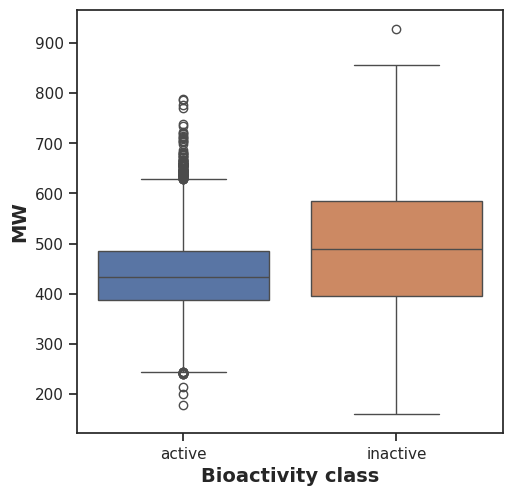

In [59]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('boxplot_MW.pdf')

logP

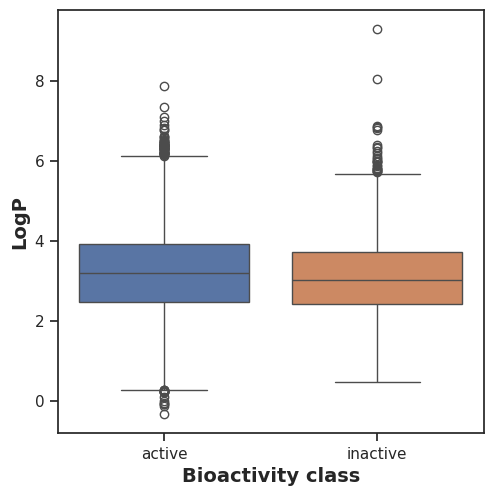

In [61]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = 'LogP', data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('boxplot_LogP.pdf')

NumHDonors

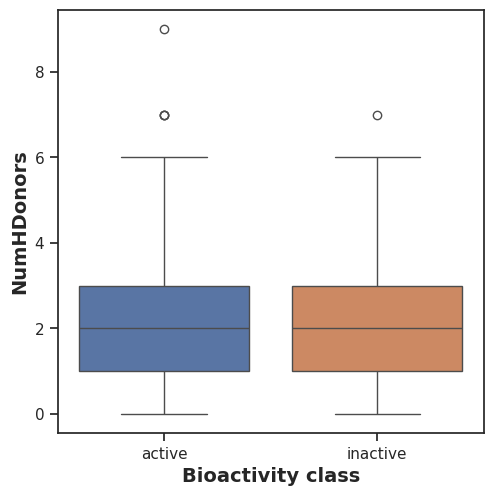

In [62]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHDonors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHDonors.pdf')

NumHAcceptors

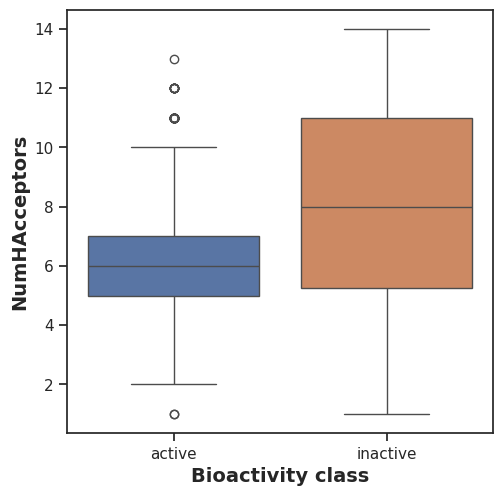

In [63]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "bioactivity_class", y = "NumHAcceptors", data = df_combined, hue="bioactivity_class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHAcceptors.pdf')


Save & Downlaod Results

In [64]:
! zip -r EDA_results.zip . -i *df_lipinski.csv *mannwhitney_summary.csv *.pdf

  adding: boxplot_NumHAcceptors.pdf (deflated 37%)
  adding: histogram_pic50.pdf (deflated 49%)
  adding: boxplot_LogP.pdf (deflated 37%)
  adding: df_lipinski.csv (deflated 80%)
  adding: boxplot_NumHDonors.pdf (deflated 37%)
  adding: barplot_bioactivity_class.pdf (deflated 38%)
  adding: mannwhitney_summary.csv (deflated 47%)
  adding: boxplot_MW.pdf (deflated 34%)
  adding: scatter_plot_MW_vs_LogP.pdf (deflated 2%)


# 3. Descriptor Calculation

PaDELPy is a Python wrapper for the PaDEL-Descriptor (molecular descriptor calculation) software.

It provide the following descriptors/fingerprint:

1444 - 2D Descriptors
431 - 3D Descriptors
881 bits - PubChem Fingerprints

### Installing Dependencies & libraries

In [65]:
!pip install padelpy

import pandas as pd
import numpy as np
from google.colab import files
from padelpy import padeldescriptor

df = pd.read_csv('df_lipinski.csv')
df.head()




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 77.4 MB/s eta 0:00:00


,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL4242999,active,6.897909,NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2,326.400,2.0133,4.0,4.0
1,CHEMBL3918308,active,8.522879,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,334.221,3.2743,1.0,3.0
2,CHEMBL3942304,active,7.148742,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,496.232,4.5717,1.0,5.0
3,CHEMBL3927649,active,8.214670,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,411.307,3.7477,1.0,4.0
4,CHEMBL3979340,active,8.552842,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,401.268,3.3407,1.0,5.0


In [66]:
data = df[['canonical_smiles', 'molecule_chembl_id']]
data.head()

,canonical_smiles,molecule_chembl_id
0,NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2,CHEMBL4242999
1,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,CHEMBL3918308
2,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,CHEMBL3942304
3,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,CHEMBL3927649
4,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,CHEMBL3979340


Convert to .smi format

In [67]:
df_smi = data['canonical_smiles'].to_csv('smiles_chembl.smi', index=None, header=None)

In [68]:
! cat smiles_chembl.smi | head

NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2
BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1
Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br
Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1
Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1
Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1
Brc1csc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)c1
Brc1nc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br
Brc1ncc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)s1
C#CCC1(n2cc(-c3c(C)n[nH]c3C)cn2)CN(c2cnc(C(=O)NC(C)C)cn2)C1


Calculate molecular Pubchem Fingerprints using "padeldescriptor" function

In [69]:
padeldescriptor(mol_dir= "smiles_chembl.smi",
                d_file='pubchem_fingerprints.csv',
                fingerprints = True,
                retainorder= True,
                #removesalt = True, standardizetautomers = True, standardizenitro=True
                )

In [70]:
!ls -lh pubchem_fingerprints.csv

-rw-r--r-- 1 root root 19M Apr 27 13:11 pubchem_fingerprints.csv


In [71]:
df_fingerprint = pd.read_csv("pubchem_fingerprints.csv")
df_fingerprint.head()

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,AUTOGEN_smiles_chembl_1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AUTOGEN_smiles_chembl_2,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AUTOGEN_smiles_chembl_3,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AUTOGEN_smiles_chembl_4,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AUTOGEN_smiles_chembl_5,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Prepare Dataset for ML

In [72]:
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL4242999,active,6.897909,NC(=O)c1cnc2[nH]ccc2c1NC1C2CC3CC1CC(O)(C3)C2,326.400,2.0133,4.0,4.0
1,CHEMBL3918308,active,8.522879,BrC[C@H]1CC[C@H](c2nnn3cnc4[nH]ccc4c23)CC1,334.221,3.2743,1.0,3.0
2,CHEMBL3942304,active,7.148742,Brc1cc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)sc1Br,496.232,4.5717,1.0,5.0
3,CHEMBL3927649,active,8.214670,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)cc1,411.307,3.7477,1.0,4.0
4,CHEMBL3979340,active,8.552842,Brc1ccc(CN2CCC(c3nnn4cnc5[nH]ccc5c34)CC2)o1,401.268,3.3407,1.0,5.0


In [73]:
# Select only the columns we need for ML
meta_cols = df[['molecule_chembl_id', 'bioactivity_class', 'pIC50']]

# Reset index to ensure proper alignment
meta_cols = meta_cols.reset_index(drop=True)
df_fingerprint = df_fingerprint.reset_index(drop=True)

# Combine meta data with fingerprints
combined_df = pd.concat([meta_cols, df_fingerprint.drop(df_fingerprint.columns[0], axis=1)], axis=1)

# Inspect the first few rows
combined_df.head()


,molecule_chembl_id,bioactivity_class,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL4242999,active,6.897909,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL3918308,active,8.522879,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL3942304,active,7.148742,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL3927649,active,8.214670,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL3979340,active,8.552842,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Save and download the dataset

In [74]:
# Save as CSV
combined_df.to_csv("QSAR_dataset.csv", index=False)
print("Combined dataset saved as QSAR_dataset.csv")

# Download file in Colab
files.download("QSAR_dataset.csv")

Combined dataset saved as QSAR_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Calculate other fingerprints

Download xml Files from Github

In [75]:
!wget https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip

!unzip padel_descriptors_xml.zip


--2026-04-27 13:11:18--  https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip [following]
--2026-04-27 13:11:18--  https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10871 (11K) [application/zip]
Saving to: ‘padel_descriptors_xml.zip’

padel_descriptors_x 100%[=============

Calculate Fingerprints

In [76]:
# Specify the XML file for SubstructureFingerprinter directly
Substruc_fp = "SubstructureFingerprinter.xml"

# Calculate Substructure fingerprints, (extra-part)
padeldescriptor(
    mol_dir='smiles_chembl.smi',
    d_file='Substructure_fingerprints.csv',
    fingerprints=True,
    descriptortypes= Substruc_fp,
    retainorder=True
    # removesalt=True, standardizetautomers=True
)

#4. QSAR Modeling

Random forest Regression model to predict pIC50 values


In [77]:
# Install LazyPredict
!pip install lazypredict
# Install SHAP
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.7 MB/s eta 0:00:00


In [78]:
# Import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.utils import shuffle
from lazypredict.Supervised import LazyRegressor
import shap

###Loading the Dataset

In [79]:
df = pd.read_csv('QSAR_dataset.csv')
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL4242999,active,6.897909,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL3918308,active,8.522879,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL3942304,active,7.148742,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL3927649,active,8.214670,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL3979340,active,8.552842,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Dataset overview:
molecule_chembl_id: Unique molecule ID
bioactivity_class: Active/inactive class
pIC50: Continuous potency value (4-9)
PubchemFP0 to PubchemFP880: 881 binary fingerprints

Features (X) and Target (y)


In [80]:
# Exclude non-feature columns
non_feature_cols = ['molecule_chembl_id', 'bioactivity_class', 'pIC50']
X = df.drop(columns=non_feature_cols)
print(X.shape)

(10615, 881)


In [81]:
# Target variable
y_reg = df['pIC50']
y_reg


,pIC50
0,6.897909
1,8.522879
2,7.148742
3,8.214670
4,8.552842
...,...
10610,7.698970
10611,8.000000
10612,7.267606
10613,7.420216


Feature Selection – Variance Threshold
Not all 881 fingerprints are informative. Low-variance features (mostly 0 or 1) add noise. So we remove them.

In [82]:
# Apply variance threshold
selection = VarianceThreshold(threshold=(0.8*(1-0.8)))  # Threshold = 0.16
X_var = selection.fit_transform(X)

# Extract the correct feature names
selected_mask = selection.get_support()
feature_names = X.columns[selected_mask]

# Convert immediately to DataFrame
X_var = pd.DataFrame(X_var, columns=feature_names)

print('After variance threshold:', X_var.shape)

After variance threshold: (10615, 123)


### Split Data into Training and Test Set

Training set size: 8492 molecules
Testing set size: 2123 molecules


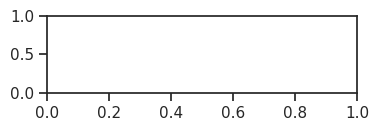

In [83]:
# Split into 80/20 train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_var, y_reg, test_size=0.2, random_state=123
)
print(f'Training set size: {X_train_reg.shape[0]} molecules')
print(f'Testing set size: {X_test_reg.shape[0]} molecules')

Build and Train Random Forest Model

In [93]:
np.random.seed(123)

rf_model = RandomForestRegressor(n_estimators=200)

# Filter out infinite values from y_train_reg and corresponding X_train_reg
finite_indices = np.isfinite(y_train_reg)
X_train_reg_filtered = X_train_reg[finite_indices]
y_train_reg_filtered = y_train_reg[finite_indices]

# Train model using filtered data
rf_model.fit(X_train_reg_filtered, y_train_reg_filtered)

RandomForestRegressor(n_estimators=200)

Evaluate Model's Performance on Test Set

In [88]:
finite_indices_test = np.isfinite(y_test_reg)
X_test_reg_filtered = X_test_reg[finite_indices_test]
y_test_reg_filtered = y_test_reg[finite_indices_test]

r2 = rf_model.score(X_test_reg_filtered, y_test_reg_filtered)
print(f'Random Forest R² score: {r2:.4f}')

Random Forest R² score: 0.7607


**R² interpretation:**

R² < 0.4 → Poor fit.

R² < 0.5-0.7 → Moderate/Acceptable.

R² > 0.9 → Very good/High fit

Make Predictions on test set

In [91]:
# Predict on test set
y_pred_reg = rf_model.predict(X_test_reg)

In [92]:
y_pred_reg

array([ 9.12423565,  8.02452724,  7.50302741, ...,  8.00025082,
        5.92127795, 10.22061266])

*Visualize Predictions vs Actual Values*

/usr/local/lib/python3.12/dist-packages/numpy/_core/function_base.py:168: RuntimeWarning: invalid value encountered in multiply
  y *= step
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


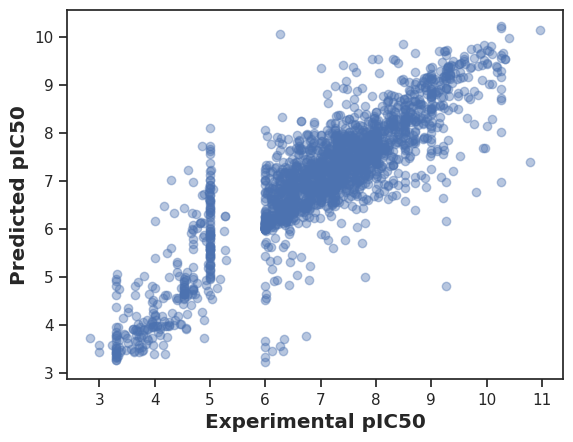

In [94]:
ax = sns.regplot(x=y_test_reg, y=y_pred_reg, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
plt.show()

Y-Randomization – Validate Model


Y-Randomization Test Results:
Mean R² with shuffled Y: -0.2139
Actual RF R²: 0.7607


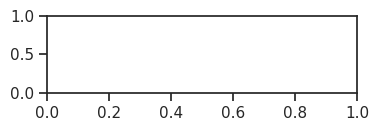

In [96]:
n_iterations = 5
random_r2_scores = []

# Filter y_train_reg to remove infinite values for Y-randomization
finite_indices_y_train = np.isfinite(y_train_reg)
X_train_reg_finite = X_train_reg[finite_indices_y_train]
y_train_reg_finite = y_train_reg[finite_indices_y_train]

# Filter y_test_reg and X_test_reg as well, in case they contain infinites
finite_indices_y_test = np.isfinite(y_test_reg)
X_test_reg_finite = X_test_reg[finite_indices_y_test]
y_test_reg_finite = y_test_reg[finite_indices_y_test]

for i in range(n_iterations):
    y_train_shuffled = shuffle(y_train_reg_finite, random_state=i)
    rf_random = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_random.fit(X_train_reg_finite, y_train_shuffled)
    y_pred_random = rf_random.predict(X_test_reg_finite)
    r2_random = r2_score(y_test_reg_finite, y_pred_random)
    random_r2_scores.append(r2_random)

print('\nY-Randomization Test Results:')
print(f'Mean R² with shuffled Y: {np.mean(random_r2_scores):.4f}')
print(f'Actual RF R²: {r2:.4f}')

Interpretation

Actual RF R2 = 0.7607

Validation Random R2 = -0.2139 (~ -0.2, acceptable)

### *LazyPredict – Compare Multiple Regression Models*

In [99]:
print('\n' + '='*60)
print('LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS')
print('='*60)

# Initialize LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit all models using the filtered data
models, predictions = reg.fit(X_train_reg_filtered, X_test_reg_filtered, y_train_reg_filtered, y_test_reg_filtered)

# Display results
print(models.head(10))  # Top 10 models


LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS
                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
RandomForestRegressor                    0.745761   0.760505  0.707996   
XGBRegressor                             0.740231   0.755295  0.715655   
BaggingRegressor                         0.723029   0.739091  0.738970   
KNeighborsRegressor                      0.715061   0.731585  0.749524   
HistGradientBoostingRegressor            0.700896   0.718241  0.767929   
NuSVR                                    0.700080   0.717473  0.768975   
SVR                                      0.698056   0.715566  0.771567   
LGBMRegressor                            0.676000   0.694790  0.799249   
MLPRegressor                             0.672058   0.691075  0.804098   
ExtraTreesRegressor                      0.622301   0.644205  0.862944   

                               Time Taken  
Model          

### Visualize Top Models

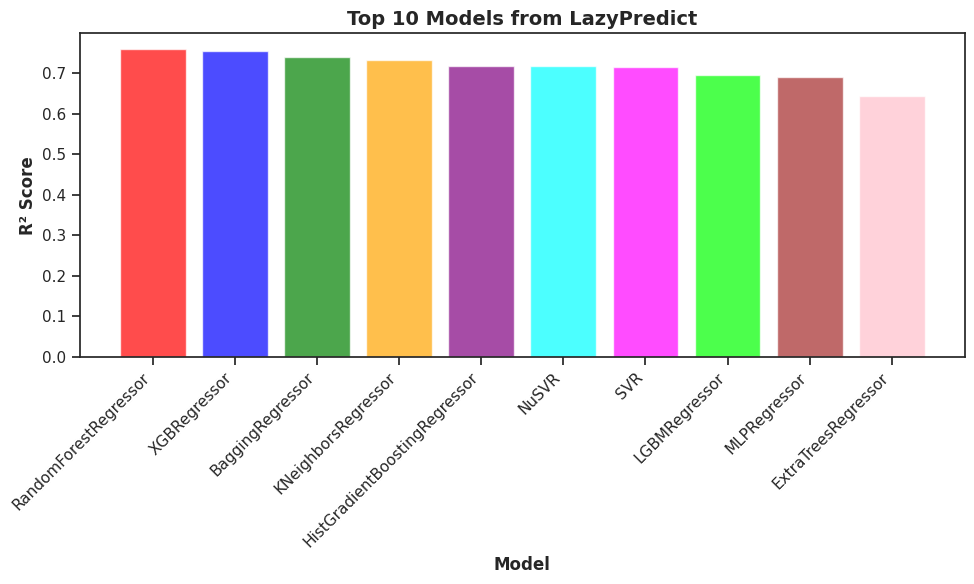

In [100]:
top_models = models.head(10)

plt.figure(figsize=(10, 6))

# Define distinct colors for each bar
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'lime', 'brown', 'pink']

# Vertical bar plot with multiple colors and alpha for transparency
plt.bar(top_models.index, top_models['R-Squared'], color=colors, alpha=0.7)

plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.title('Top 10 Models from LazyPredict', fontsize=14, fontweight='bold')

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Compare Best Model with Random Forest

In [101]:
best_model_name = models.index[0]
best_r2 = models['R-Squared'].iloc[0]
print(f'Best model from LazyPredict: {best_model_name}')
print(f'Best R² score: {best_r2:.4f}')
print(f'Random Forest R²: {r2:.4f}')
print(f'Improvement: {(best_r2 - r2)*100:.2f}%')

# Check Random Forest rank
if 'RandomForestRegressor' in models.index:
    rf_rank = models.index.get_loc('RandomForestRegressor') + 1
    print(f'Random Forest ranked: {rf_rank} out of {len(models)}')

Best model from LazyPredict: RandomForestRegressor
Best R² score: 0.7605
Random Forest R²: 0.7607
Improvement: -0.02%
Random Forest ranked: 1 out of 42


Random Forest Feature Importances using SHAP values

In [ ]:
# Create an explainer and calculate SHAP values for the test set
explainer = shap.Explainer(rf_model)
shap_values = explainer(X_test_reg)

# Summary plot
shap.summary_plot(shap_values, X_test_reg, feature_names= feature_names)